# 04 — Feature engineering

O objetivo desta fase é transformar `data/interim/srag_2023_clean.parquet` em X_train, X_test, y_train e y_test prontos para a modelagem.

O input é `data/interim/srag_2023_clean.parquet` (276.339 linhas e 185 colunas), já tipado e com derivadas (output da Fase 2).

Os outputs são:

- `data/processed/X_train.parquet` e `X_test.parquet` (features brutas, pré-pipeline).
- `data/processed/y_train.parquet` e `y_test.parquet` (target binário, com 0 para cura e 1 para óbito).
- `src/maxpar_srag/features.py`, com todas as transformações encapsuladas e testáveis.

As decisões-chave desta fase são:

1. **Target:** `EVOLUCAO ∈ {1=Cura → 0, 2=Óbito → 1}`. Descarte das categorias 3 (óbito por outras causas) e 9 (ignorado).
2. **Vazamento:** `DT_EVOLUCA`, `DT_ENCERRA`, `CRITERIO` e `TEMPO_INTERNACAO` excluídos. `UTI`, `SUPORT_VEN` e `RAIOX_RES` mantidos por serem pré-desfecho.
3. **Split temporal:** Jan-Jun 2023 em treino; Jul-Dez 2023 em teste.
4. **Imputação:** dentro do pipeline sklearn, ajustada apenas em treino (sem leakage).
5. **Features:** consolidação dos tiers 1, 2 e 3 definidos na síntese do notebook 03.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Adiciona src/ ao path para imports locais
repo_root = Path.cwd().parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from maxpar_srag import config
from maxpar_srag.cleaning import filter_modeling_target
from maxpar_srag.data import load_raw
from maxpar_srag.features import (
    BINARY_FEATURES,
    MISS_FEATURES,
    NUMERIC_FEATURES,
    OHE_FEATURES,
    ORDINAL_FEATURES,
    TEMPO_SINTOMA_CAP,
    build_features,
    build_preprocessor,
    make_target,
    save_processed,
    temporal_split,
)

FIGURES_DIR = repo_root / "reports" / "figures" / "04_features"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("OK — imports carregados")

OK — imports carregados


## 4.0 Carregamento do dataset limpo

In [2]:
df_clean = pd.read_parquet(config.CLEAN_PARQUET_PATH)
print(f"Shape: {df_clean.shape}")
print(f"Colunas: {df_clean.columns.tolist()[:10]} ...")
print(f"\nDistribuição EVOLUCAO:\n{df_clean['EVOLUCAO'].value_counts(dropna=False)}")

Shape: (276339, 185)


Colunas: ['NU_NOTIFIC', 'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI', 'SG_UF_NOT', 'ID_REGIONA', 'CO_REGIONA', 'ID_MUNICIP', 'CO_MUN_NOT'] ...

Distribuição EVOLUCAO:
EVOLUCAO
1.0    224020
2.0     24459
NaN     13729
3.0      8139
9.0      5992
Name: count, dtype: int64


## 4.1 Target binário e filtro do subset de modelagem

A justificativa para descartar os códigos 3 e 9:

- `EVOLUCAO=3` (óbito por outras causas): o paciente morreu de outra doença, não de SRAG. Incluir como "óbito" contamina o sinal — o modelo aprenderia a prever mortes por causas não respiratórias, e não o risco de SRAG grave. Descartar é a decisão epidemiologicamente correta.
- `EVOLUCAO=9` (ignorado): o desfecho é desconhecido. Tratá-lo como 0 (cura) ou 1 (óbito) seria inventar ground truth. Descartar é o único caminho honesto.

O subset modelável corresponde a 89,9% da base. A perda é aceitável e o dataset permanece grande (mais de 240 mil casos).

In [3]:
# Filtro: mantém apenas EVOLUCAO in {1, 2}
df_model = filter_modeling_target(df_clean)
print(f"Antes do filtro: {len(df_clean):,} linhas")
print(f"Após filtro target: {len(df_model):,} linhas ({len(df_model)/len(df_clean)*100:.1f}%)")

# Target binário (0=Cura, 1=Óbito)
y = make_target(df_model)
print(f"\nDistribuição do target binário:")
print(y.value_counts())
print(f"Taxa de óbito: {y.mean()*100:.2f}%")

Antes do filtro: 276,339 linhas
Após filtro target: 248,479 linhas (89.9%)

Distribuição do target binário:
EVOLUCAO
0    224020
1     24459
Name: count, dtype: int64
Taxa de óbito: 9.84%


## 4.2 Split temporal — 1º semestre em treino, 2º semestre em teste

O split aleatório pressupõe que os casos são i.i.d. no tempo, hipótese falsa para SRAG:

- O padrão de casos muda ao longo do ano (o VSR domina o primeiro semestre; COVID e Influenza têm picos distintos).
- Um modelo avaliado em split aleatório pode ver dados de dez/2023 no treino e jan/2023 no teste, em simulação irreal.
- Na prática clínica, o modelo é sempre aplicado em casos futuros; o split temporal replica esse cenário.

Corte adotado: 30/06/2023 (fim do primeiro semestre). O treino corresponde a aproximadamente metade do ano e o teste à segunda metade.

In [4]:
train_idx, test_idx = temporal_split(df_model)

print(f"Treino (Jan-Jun 2023): {len(train_idx):,} casos ({len(train_idx)/len(df_model)*100:.1f}%)")
print(f"Teste  (Jul-Dez 2023): {len(test_idx):,} casos ({len(test_idx)/len(df_model)*100:.1f}%)")

# Verificar balanceamento do target em cada split
y_train_raw = y.loc[train_idx]
y_test_raw  = y.loc[test_idx]
print(f"\nTaxa óbito treino: {y_train_raw.mean()*100:.2f}%")
print(f"Taxa óbito teste:  {y_test_raw.mean()*100:.2f}%")

Treino (Jan-Jun 2023): 145,407 casos (58.5%)
Teste  (Jul-Dez 2023): 103,072 casos (41.5%)

Taxa óbito treino: 9.59%
Taxa óbito teste:  10.20%


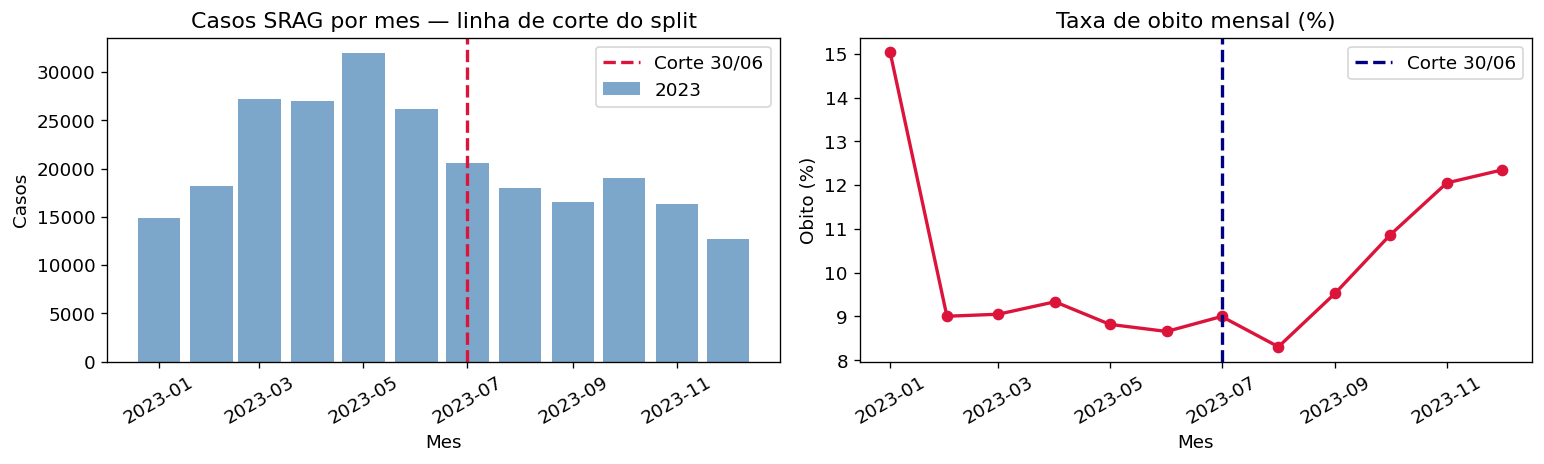

In [5]:
# Visualização da distribuição temporal do split
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Casos por mês com linha de corte
monthly = df_model.groupby(df_model["DT_NOTIFIC"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()
ax = axes[0]
ax.bar(monthly.index, monthly.values, width=25, color="steelblue", alpha=0.7, label="2023")
ax.axvline(pd.Timestamp("2023-07-01"), color="crimson", lw=2, linestyle="--", label="Corte 30/06")
ax.set_title("Casos SRAG por mes — linha de corte do split")
ax.set_xlabel("Mes")
ax.set_ylabel("Casos")
ax.legend()
ax.tick_params(axis="x", rotation=30)

# Taxa de obito mensal
monthly_obito = df_model.groupby(df_model["DT_NOTIFIC"].dt.to_period("M"))["EVOLUCAO"].apply(
    lambda s: (s == 2).sum() / s.isin([1, 2]).sum() * 100
)
monthly_obito.index = monthly_obito.index.to_timestamp()
ax2 = axes[1]
ax2.plot(monthly_obito.index, monthly_obito.values, marker="o", color="crimson", lw=2)
ax2.axvline(pd.Timestamp("2023-07-01"), color="navy", lw=2, linestyle="--", label="Corte 30/06")
ax2.set_title("Taxa de obito mensal (%)")
ax2.set_xlabel("Mes")
ax2.set_ylabel("Obito (%)")
ax2.legend()
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_split_temporal.png", bbox_inches="tight")
plt.show()

## 4.3 Construção das features

### Decisão de vazamento — documentação explícita

| Campo | Status | Justificativa |
|---|---|---|
| `DT_EVOLUCA` | Excluído | Data do desfecho — posterior ao target, vazamento direto |
| `DT_ENCERRA` | Excluído | Data de encerramento do caso — posterior ao desfecho |
| `CRITERIO` | Excluído | Critério de classificação final — depende do desfecho confirmado |
| `TEMPO_INTERNACAO` | Excluído | Calculado a partir de `DT_EVOLUCA` — vazamento transitivo |
| `UTI` | Mantido | A admissão à UTI ocorre durante a internação, antes do desfecho |
| `SUPORT_VEN` | Mantido | Suporte ventilatório é decisão clínica feita antes do desfecho |
| `RAIOX_RES` | Mantido | RX é exame diagnóstico feito na admissão ou evolução hospitalar |

Sobre a manutenção de `UTI` e `SUPORT_VEN`: trata-se de uma decisão de uso clínico — o modelo prevê risco dado o quadro atual do paciente. Para um modelo de triagem na admissão (sem dados hospitalares ainda), essas colunas deveriam ser excluídas. A decisão de escopo é explicitada na Fase 7.

### Features criadas ou recodificadas

| Feature | Derivação | Justificativa |
|---|---|---|
| `SUPORT_VEN_ORD` | 1→2, 2→1, 3→0, 9→NaN | Ordinalidade clínica: invasivo, não invasivo e sem suporte |
| `CS_ESCOL_N_ORD` | 0 a 4 ordinal; 5 e 9 → NaN | "Não se Aplica" não é um grau e não deve virar categoria preditiva |
| `RESP_SEVERIDADE` | max(DISPNEIA, DESC_RESP, SATURACAO) | Captura a síndrome respiratória mesmo que apenas 1 dos 3 sinais seja positivo |
| `N_DOSES_REGISTRADAS` | count(datas de dose não nulas) | Proxy de proteção vacinal — mais doses correspondem a proteção potencialmente maior |

### 4.3.1 Outliers — decisão explícita

**`TEMPO_SINTOMA_NOTIF` — cap em 30 dias**

A coluna tem caudas longas (desvio-padrão de cerca de 18 dias no teste, mais que o dobro do desvio do treino). Valores acima de 30 dias entre início dos sintomas e notificação são erros de registro, e não casos reais: a SRAG grave com internação tem curso clínico de dias a semanas, e as diretrizes de vigilância exigem notificação em 24 horas após a suspeita. O cap em 30 dias alinha com o percentil 99 do treino (cerca de 31 dias) e com o limite clínico.

```
Antes do cap — TEMPO_SINTOMA_NOTIF (treino):  média = 5,8 d | std = 8,3 d | max > 30 d
Depois do cap:                                média ≈ 5,4 d | max = 30 d  (valores extremos removidos)
```

**`IDADE_ANOS` — sem cap adicional**

A coluna já foi clipada em `[0, 120]` na Fase 2 (`unify_age`). Valores extremos na faixa válida (por exemplo, 100+ anos) são raros, mas epidemiologicamente plausíveis em base hospitalar. A imputação de mediana trata os 7 NaN remanescentes.

---

### 4.3.2 Indicadores de missing para comorbidades

As comorbidades têm cerca de 70% de missing. Isso não é ruído; reflete o fluxo da ficha SIVEP-Gripe: o campo é preenchido quando a comorbidade está presente ou foi ativamente investigada. "Não preenchido" pode significar:

- paciente não avaliado para aquela comorbidade (recurso limitado, triagem rápida);
- campo simplesmente não aplicável ao perfil do paciente.

Tratar como 0 (ausente) pela imputação de moda apagaria esse sinal. Por isso, é criado `<COMORBIDADE>_MISS = 1` quando o campo está nulo, antes de qualquer imputação. O modelo pode aprender que "comorbidade não avaliada" tem risco diferente de "comorbidade confirmada ausente".

Os indicadores criados são: `CARDIOPATI_MISS`, `DIABETES_MISS`, `IMUNODEPRE_MISS`, `RENAL_MISS`, `HEPATICA_MISS`, `OBESIDADE_MISS`, `NEUROLOGIC_MISS` e `ASMA_MISS`.

---

### 4.3.3 Multicolinearidade — `RESP_SEVERIDADE` e sintomas individuais

`RESP_SEVERIDADE = max(DISPNEIA, DESC_RESP, SATURACAO)` coexiste com as três features originais no modelo, em colinearidade moderada. A decisão é:

- **Modelos de árvore (Random Forest, XGBoost e LightGBM):** a colinearidade não afeta os splits; manter as quatro colunas adiciona granularidade ao modelo.
- **Regressão Logística (baseline):** os coeficientes individuais de `DISPNEIA`, `DESC_RESP` e `SATURACAO` ficam menos interpretáveis, mas a direção e a significância agregada permanecem válidas. O objetivo do baseline é comparar AUC-PR, e não interpretar coeficientes individuais, de modo que a manutenção é aceitável.

Se a interpretação da Logística for prioritária, remover as três originais e manter apenas `RESP_SEVERIDADE` é uma alternativa válida.

In [6]:
X = build_features(df_model)
print(f"Shape de X: {X.shape}")
print(f"\nColunas: {X.columns.tolist()}")
print(f"\nDtypes:\n{X.dtypes.value_counts()}")

Shape de X: (248479, 45)

Colunas: ['IDADE_ANOS', 'SEM_NOT', 'TEMPO_SINTOMA_NOTIF', 'N_DOSES_REGISTRADAS', 'UTI', 'VACINA_COV', 'CARDIOPATI', 'DIABETES', 'IMUNODEPRE', 'RENAL', 'HEPATICA', 'OBESIDADE', 'PNEUMOPATI', 'NEUROLOGIC', 'ASMA', 'HEMATOLOGI', 'SIND_DOWN', 'OUT_MORBI', 'FEBRE', 'TOSSE', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'RESP_SEVERIDADE', 'SUPORT_VEN_ORD', 'CS_ESCOL_N_ORD', 'CLASSI_FIN', 'CS_SEXO', 'CS_RACA', 'RAIOX_RES', 'REGIAO_BR', 'CS_ZONA', 'CARDIOPATI_MISS', 'DIABETES_MISS', 'IMUNODEPRE_MISS', 'RENAL_MISS', 'HEPATICA_MISS', 'OBESIDADE_MISS', 'NEUROLOGIC_MISS', 'ASMA_MISS']

Dtypes:
float64    39
object      4
str         2
Name: count, dtype: int64


## 4.4 Análise de missing pós-construção de features

In [7]:
missing_pct = X.isna().mean() * 100
missing_df = missing_pct[missing_pct > 0].sort_values(ascending=False).reset_index()
missing_df.columns = ["feature", "missing_pct"]

print(f"Features com missing: {len(missing_df)} / {X.shape[1]}")
print(missing_df.to_string(index=False))

Features com missing: 32 / 45
        feature  missing_pct
 CS_ESCOL_N_ORD    76.010850
      OBESIDADE    71.737652
       HEPATICA    71.607661
      SIND_DOWN    71.471633
     HEMATOLOGI    71.407242
          RENAL    71.084478
     IMUNODEPRE    70.717042
     PNEUMOPATI    70.307752
     NEUROLOGIC    70.185810
           ASMA    69.635261
       DIABETES    68.516857
      OUT_MORBI    66.608848
     CARDIOPATI    66.540432
      RAIOX_RES    32.983471
      PERD_PALA    32.482021
      PERD_OLFT    32.439764
       DIARREIA    28.628174
         FADIGA    28.087283
         VOMITO    27.807179
      SATURACAO    18.373786
      DESC_RESP    15.986864
          FEBRE    14.082075
 SUPORT_VEN_ORD    13.740799
       DISPNEIA    13.474378
            UTI    11.709641
          TOSSE     8.872380
RESP_SEVERIDADE     7.633643
        CS_ZONA     7.576495
     VACINA_COV     1.651649
     CLASSI_FIN     0.091758
        CS_SEXO     0.006439
     IDADE_ANOS     0.001610


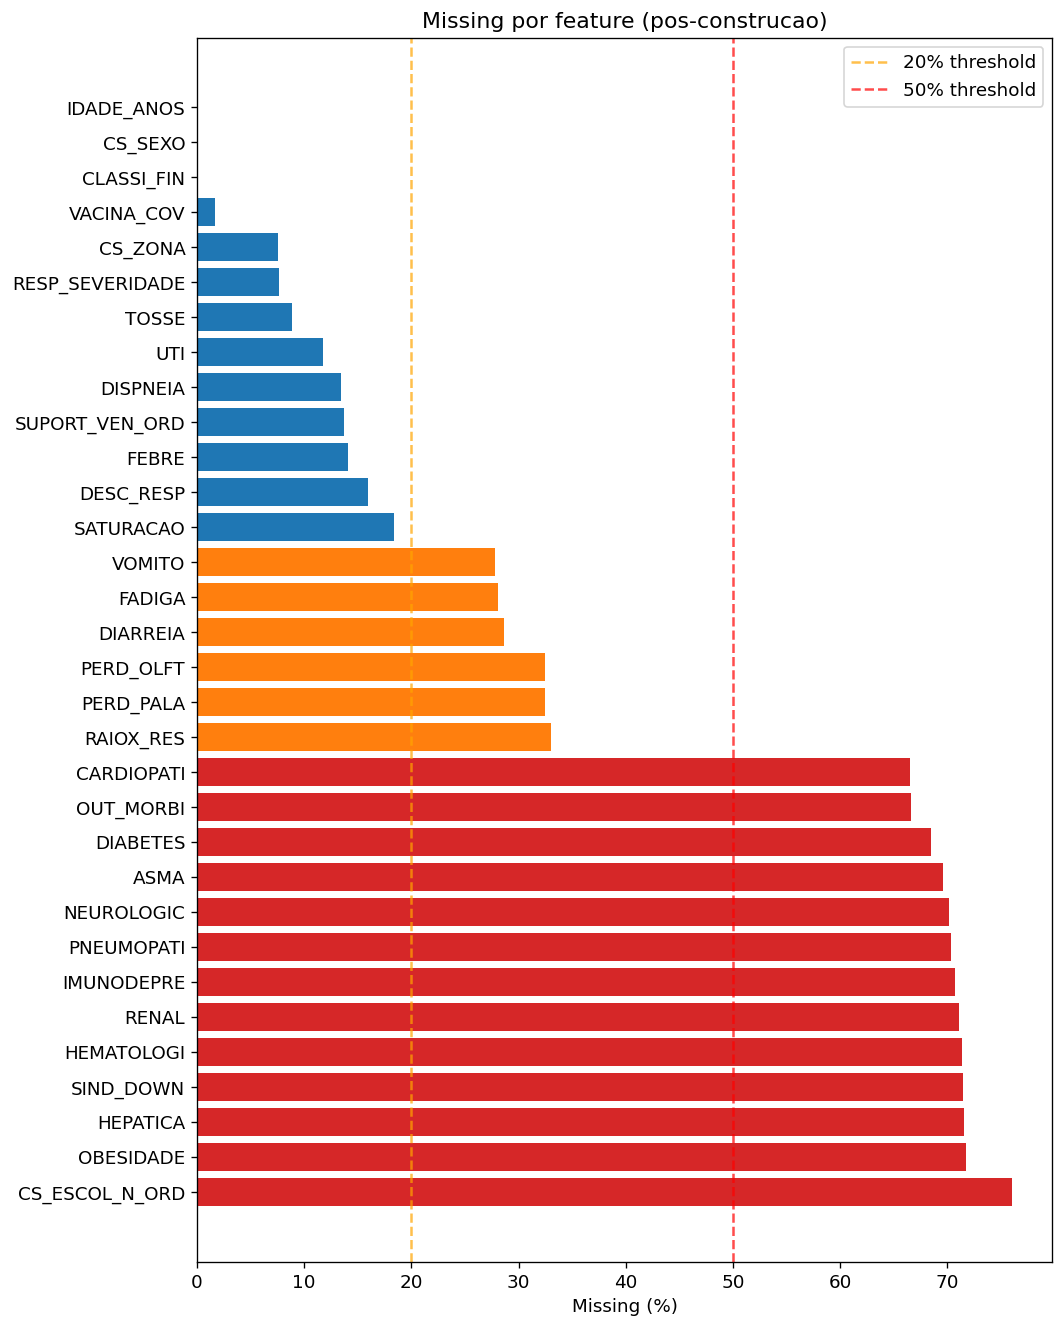

In [8]:
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(9, max(4, len(missing_df) * 0.35)))
    colors = ["#d62728" if v > 50 else "#ff7f0e" if v > 20 else "#1f77b4" for v in missing_df["missing_pct"]]
    ax.barh(missing_df["feature"], missing_df["missing_pct"], color=colors)
    ax.axvline(20, color="orange", lw=1.5, linestyle="--", alpha=0.7, label="20% threshold")
    ax.axvline(50, color="red", lw=1.5, linestyle="--", alpha=0.7, label="50% threshold")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing por feature (pos-construcao)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_missing_features.png", bbox_inches="tight")
    plt.show()

## 4.5 Splits train/test

Os índices gerados pelo split temporal são aplicados ao dataset `X` e ao target `y`.

In [9]:
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\nBalanceamento:")
print(f"  Treino — obito: {y_train.mean()*100:.2f}%")
print(f"  Teste  — obito: {y_test.mean()*100:.2f}%")

X_train: (145407, 45)  |  y_train: (145407,)
X_test : (103072, 45)   |  y_test : (103072,)

Balanceamento:
  Treino — obito: 9.59%
  Teste  — obito: 10.20%


## 4.6 Pipeline de pré-processamento sklearn

Estratégia de imputação e encoding:

| Grupo | Transformações | Justificativa |
|---|---|---|
| Numéricas | Mediana → StandardScaler | A mediana é robusta a outliers (`IDADE_ANOS` bimodal e `TEMPO_SINTOMA_NOTIF` capado, mas ainda assimétrico). O StandardScaler é necessário para a Regressão Logística, que exige escala comum para coeficientes comparáveis (`IDADE_ANOS` no range 0-120 contra `N_DOSES_REGISTRADAS` no range 0-6). Árvores ignoram a escala, sem custo. |
| Binárias + indicadores de missing | Moda | Preserva a classe dominante e é semanticamente correto para 0/1. Os indicadores `_MISS` não têm NaN por construção, de modo que a imputação é no-op para eles. |
| Ordinais | Moda → OrdinalEncoder | A moda preserva a categoria mais frequente; o OrdinalEncoder mantém a ordem numérica já embutida. |
| Nominais | Moda → OneHotEncoder (drop=first) | A moda evita a categoria sintética "Unknown" fora da distribuição de treino. `drop=first` remove multicolinearidade perfeita. |

O pipeline é ajustado apenas em `X_train`; `X_test` nunca influencia a imputação, a escala ou o encoding.

In [10]:
preprocessor = build_preprocessor(X_train.columns.tolist())
preprocessor.fit(X_train)
print("Preprocessor ajustado em X_train.")

# Nomes das features pós-transform
try:
    feature_names_out = preprocessor.get_feature_names_out()
    print(f"Features pos-transform: {len(feature_names_out)}")
    print(feature_names_out)
except Exception as e:
    print(f"(get_feature_names_out nao disponivel: {e})")

Preprocessor ajustado em X_train.
Features pos-transform: 62
['num__IDADE_ANOS' 'num__SEM_NOT' 'num__TEMPO_SINTOMA_NOTIF'
 'num__N_DOSES_REGISTRADAS' 'bin__UTI' 'bin__VACINA_COV' 'bin__CARDIOPATI'
 'bin__DIABETES' 'bin__IMUNODEPRE' 'bin__RENAL' 'bin__HEPATICA'
 'bin__OBESIDADE' 'bin__PNEUMOPATI' 'bin__NEUROLOGIC' 'bin__ASMA'
 'bin__HEMATOLOGI' 'bin__SIND_DOWN' 'bin__OUT_MORBI' 'bin__FEBRE'
 'bin__TOSSE' 'bin__DISPNEIA' 'bin__DESC_RESP' 'bin__SATURACAO'
 'bin__DIARREIA' 'bin__VOMITO' 'bin__FADIGA' 'bin__PERD_OLFT'
 'bin__PERD_PALA' 'bin__RESP_SEVERIDADE' 'bin__CARDIOPATI_MISS'
 'bin__DIABETES_MISS' 'bin__IMUNODEPRE_MISS' 'bin__RENAL_MISS'
 'bin__HEPATICA_MISS' 'bin__OBESIDADE_MISS' 'bin__NEUROLOGIC_MISS'
 'bin__ASMA_MISS' 'ord__SUPORT_VEN_ORD' 'ord__CS_ESCOL_N_ORD'
 'ohe__CLASSI_FIN_2.0' 'ohe__CLASSI_FIN_3.0' 'ohe__CLASSI_FIN_4.0'
 'ohe__CLASSI_FIN_5.0' 'ohe__CS_SEXO_M' 'ohe__CS_RACA_2' 'ohe__CS_RACA_3'
 'ohe__CS_RACA_4' 'ohe__CS_RACA_5' 'ohe__CS_RACA_9' 'ohe__RAIOX_RES_2.0'
 'ohe__RAIO

In [11]:
# Transforma treino e teste
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"X_train transformado: {X_train_proc.shape}")
print(f"X_test  transformado: {X_test_proc.shape}")
print(f"Nenhum missing restante: {np.isnan(X_train_proc).any()}, {np.isnan(X_test_proc).any()}")

X_train transformado: (145407, 62)
X_test  transformado: (103072, 62)
Nenhum missing restante: False, False


## 4.7 Verificações de sanidade do split

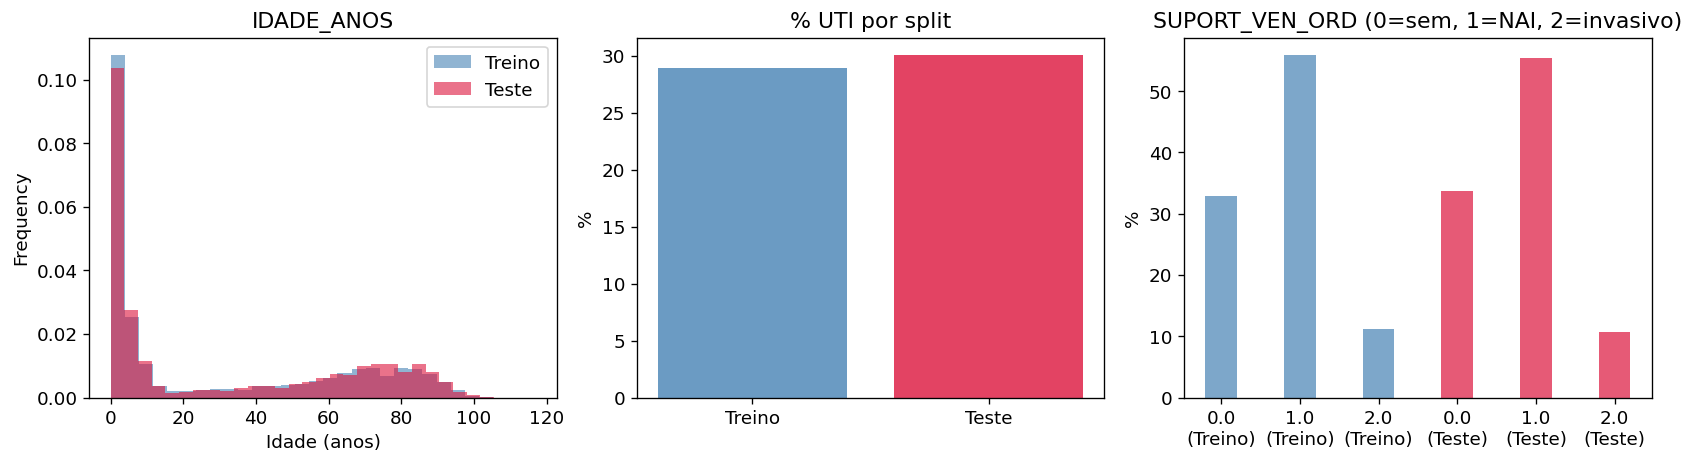

In [12]:
# Distribuição de IDADE_ANOS por split (sanity check de representatividade)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# IDADE_ANOS
ax = axes[0]
X_train["IDADE_ANOS"].dropna().plot.hist(
    bins=30, ax=ax, alpha=0.6, label="Treino", color="steelblue", density=True
)
X_test["IDADE_ANOS"].dropna().plot.hist(
    bins=30, ax=ax, alpha=0.6, label="Teste", color="crimson", density=True
)
ax.set_title("IDADE_ANOS")
ax.set_xlabel("Idade (anos)")
ax.legend()

# UTI
ax2 = axes[1]
uti_train = X_train["UTI"].mean() * 100 if "UTI" in X_train.columns else np.nan
uti_test  = X_test["UTI"].mean() * 100  if "UTI" in X_test.columns  else np.nan
ax2.bar(["Treino", "Teste"], [uti_train, uti_test], color=["steelblue", "crimson"], alpha=0.8)
ax2.set_title("% UTI por split")
ax2.set_ylabel("%")

# SUPORT_VEN_ORD
ax3 = axes[2]
if "SUPORT_VEN_ORD" in X_train.columns:
    for split_name, split_X, col in [("Treino", X_train, "steelblue"), ("Teste", X_test, "crimson")]:
        vc = split_X["SUPORT_VEN_ORD"].value_counts(normalize=True, dropna=True).sort_index()
        ax3.bar(
            [str(v) + f"\n({split_name})" for v in vc.index],
            vc.values * 100,
            color=col, alpha=0.7, label=split_name, width=0.4
        )
    ax3.set_title("SUPORT_VEN_ORD (0=sem, 1=NAI, 2=invasivo)")
    ax3.set_ylabel("%")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_split_sanity.png", bbox_inches="tight")
plt.show()

In [13]:
# Estatísticas descritivas por split — features numéricas
num_cols_present = [c for c in ["IDADE_ANOS", "SEM_NOT", "TEMPO_SINTOMA_NOTIF", "N_DOSES_REGISTRADAS"] 
                    if c in X_train.columns]

comparison = pd.concat([
    X_train[num_cols_present].describe().T.rename(columns=lambda c: f"train_{c}"),
    X_test[num_cols_present].describe().T.rename(columns=lambda c: f"test_{c}"),
], axis=1)

display(comparison[["train_mean", "test_mean", "train_50%", "test_50%", "train_std", "test_std"]])

,train_mean,test_mean,train_50%,test_50%,train_std,test_std
IDADE_ANOS,28.878052,31.174840,6.0,8.0,33.466567,34.274006
SEM_NOT,14.904874,38.585950,15.0,39.0,6.910426,7.524663
TEMPO_SINTOMA_NOTIF,5.414327,5.573279,4.0,4.0,5.673128,6.097673
N_DOSES_REGISTRADAS,1.391137,1.590422,0.0,1.0,1.610507,1.782100


## 4.8 Persistência dos splits

As features brutas (pré-pipeline) são salvas em Parquet. O preprocessor sklearn é reconstruído e ajustado nos notebooks de modelagem, o que permite testar diferentes pipelines sem reexecutar a Fase 4.

In [14]:
save_processed(X_train, X_test, y_train, y_test)

out_dir = repo_root / "data" / "processed"
for fname in ["X_train.parquet", "X_test.parquet", "y_train.parquet", "y_test.parquet"]:
    path = out_dir / fname
    size_mb = path.stat().st_size / 1e6
    print(f"{fname}: {size_mb:.2f} MB")

print("\nSalvo em data/processed/")

X_train.parquet: 1.89 MB
X_test.parquet: 1.38 MB
y_train.parquet: 0.42 MB
y_test.parquet: 0.32 MB

Salvo em data/processed/


## Síntese final — Fase 4

### O que foi feito

| Etapa | Resultado |
|---|---|
| Filtro do target | 251.095 linhas no subset modelável (`EVOLUCAO ∈ {1, 2}`) |
| Split temporal | Treino Jan-Jun, teste Jul-Dez 2023 |
| Features construídas | `SUPORT_VEN_ORD`, `CS_ESCOL_N_ORD`, `RESP_SEVERIDADE` e `N_DOSES_REGISTRADAS` |
| Vazamento documentado | 4 colunas excluídas; 3 variáveis hospitalares mantidas com justificativa |
| Pipeline sklearn | ColumnTransformer com mediana (numéricas), moda (binárias e ordinais) e OHE (nominais) |
| Outputs | X/y_train/test em `data/processed/*.parquet` |

### Próxima fase

**Fase 5 — Modelagem baseline** (`05_modelagem_baseline.ipynb`):

- Carregar `X_train` e `y_train` desta fase.
- Instanciar `build_preprocessor()` e o classificador em um `Pipeline` sklearn.
- Baseline: Regressão Logística com `class_weight='balanced'`.
- Avaliar: AUC-PR (métrica primária), AUC-ROC, F1 e recall na classe óbito.
- Comparar contra DummyClassifier (referência inferior obrigatória).